# 증감과 극값 (도함수 이용)

$f'(x)$의 부호로 증가·감소를 읽고, $f'(c)=0$ (또는 미분불가능)인 점에서 **극값**을 찾는다.

## 1. 증감표의 원리

| $f'$ | $f$ |
|------|-----|
| $f'>0$ | 증가 |
| $f'<0$ | 감소 |
| $f'=0$ | 임계점 (극값 후보) |

In [1]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

sp.init_printing()
x = sp.symbols('x', real=True)

f = x**3 - 3*x
df = sp.diff(f, x)

print("f(x) =")
display(f)
print("f'(x) =")
display(df)

crit = sorted(sp.solve(sp.Eq(df, 0), x))
print("임계점 f'=0:")
display(crit)

f(x) =


f'(x) =


임계점 f'=0:


**sp.solve(df, x)**: <br>
=> $f'(x)=0$의 실근 = 임계점

## 2. 부호 분석 → 증감

In [ ]:
# 임계점으로 실수선 분할 후 각 구간 대표점에서 f' 부호
points = crit
bounds = [-sp.oo] + list(points) + [sp.oo]

print("증감 분석")
for i in range(len(bounds) - 1):
    left, right = bounds[i], bounds[i + 1]
    if left == -sp.oo:
        test = right - 1
    elif right == sp.oo:
        test = left + 1
    else:
        test = (left + right) / 2
    sign = sp.sign(df.subs(x, test))
    mono = "증가" if sign > 0 else ("감소" if sign < 0 else "평탄")
    print(f"  구간 ({left}, {right}): f' 부호={sign}, → {mono}")

증감 분석
  구간 (-oo, -1): f' 부호=1, → 증가
  구간 (-1, 1): f' 부호=-1, → 감소
  구간 (1, oo): f' 부호=1, → 증가


## 3. 극대 · 극소

- $f'$가 $(-)$에서 $(+)$로 바뀌면 **극소**
- $f'$가 $(+)$에서 $(-)$로 바뀌면 **극대**

In [ ]:
for c in crit:
    left_sign = sp.sign(df.subs(x, c - sp.Rational(1, 10)))
    right_sign = sp.sign(df.subs(x, c + sp.Rational(1, 10)))
    fc = f.subs(x, c)
    if left_sign < 0 and right_sign > 0:
        kind = "극소"
    elif left_sign > 0 and right_sign < 0:
        kind = "극대"
    else:
        kind = "극값 아님 (변곡 등)"
    print(f"x={c}: f={fc} → {kind}")

x=-1: f=2 → 극대
x=1: f=-2 → 극소


## 4. 그래프

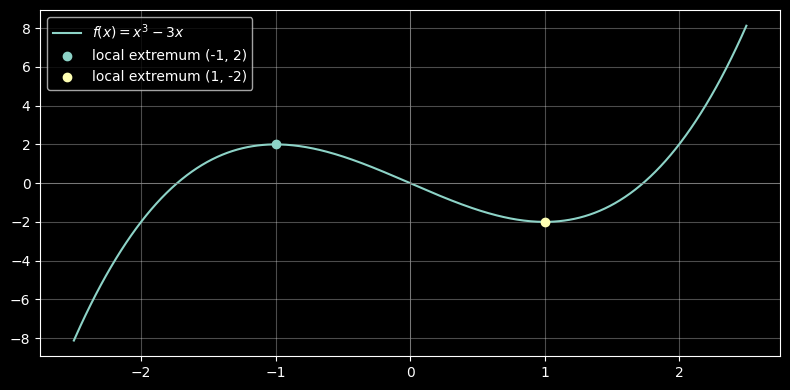

In [5]:
f_num = sp.lambdify(x, f, 'numpy')
xs = np.linspace(-2.5, 2.5, 400)
ys = f_num(xs)

plt.figure(figsize=(8, 4))
plt.plot(xs, ys, label=r"$f(x)=x^3-3x$")
for c in crit:
    plt.scatter([float(c)], [float(f.subs(x, c))], zorder=5,
                label=f"local extremum ({c}, {f.subs(x,c)})")
plt.axhline(0, color="gray", lw=0.6)
plt.axvline(0, color="gray", lw=0.6)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()